# 01 — Exploratory Data Analysis (EDA)
## Rx Drug MMIX Analysis

This notebook focuses on exploratory data analysis for the Rx drug marketing mix dataset.

### EDA goals
- understand variable distributions
- examine sales relationships with detailing and direct-to-consumer advertising
- inspect zero-value patterns in DTCA
- assess trends over time
- evaluate whether classes and agents have different baselines
- surface modeling implications for later parametric and machine learning notebooks

### Standardized column names used throughout the project
- `class`
- `agent`
- `year`
- `detailing`
- `direct_to_consumer_ad`
- `actual_sales`

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [3]:
# Load data
df = pd.read_excel("data/MMM_Drug_Data.xlsx")

df = df.rename(columns={
    "Class": "class",
    "Agent": "agent",
    "Year": "year",
    "Detailing": "detailing",
    "Direct-to-Consumer Advertising (DTCA)": "direct_to_consumer_ad",
    "Actual Sales": "actual_sales"
})

df.head()

,class,agent,year,detailing,direct_to_consumer_ad,actual_sales
0,PPI,Prevacid,2013,43.8805,0.0000,2.9083
1,PPI,Prilosec,2013,41.6480,0.0000,14.7235
2,SSRI,Luvox,2013,22.3667,0.0000,0.9120
3,SSRI,Paxil,2013,57.4608,0.0000,11.2677
4,SSRI,Prozac,2013,84.5333,0.0000,20.2600


## 1. Initial data check

This section confirms shape, column types, missing values, and the time range covered by the dataset.

In [4]:
print("Shape:", df.shape)
print("\nColumn types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nYears covered:", df["year"].min(), "to", df["year"].max())
print("Number of classes:", df["class"].nunique())
print("Number of agents:", df["agent"].nunique())

Shape: (207, 6)

Column types:


,dtype
class,str
agent,str
year,int64
detailing,float64
direct_to_consumer_ad,float64
actual_sales,float64



Missing values:


,missing_count
class,0
agent,0
year,0
detailing,0
direct_to_consumer_ad,0
actual_sales,0



Years covered: 2013 to 2024
Number of classes: 3
Number of agents: 22


In [40]:
print("\n[EDA] Checking panel structure (agent × year)...")

panel = pd.crosstab(df["agent"], df["year"])

n_agents = df["agent"].nunique()
n_years = df["year"].nunique()
expected = n_agents * n_years
actual = len(df)

print(f"Total agents: {n_agents}")
print(f"Total years: {n_years}")
print(f"Expected rows (balanced panel): {expected}")
print(f"Actual rows: {actual}")
print(f"Missing agent-year combinations: {expected - actual}")

display(panel)


[EDA] Checking panel structure (agent × year)...
Total agents: 22
Total years: 12
Expected rows (balanced panel): 264
Actual rows: 207
Missing agent-year combinations: 57


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
agent,,,,,,,,,,,,
Aciphex,0,0,0,1,1,1,1,1,1,1,1,1
Altoprev,0,0,0,0,0,0,1,1,1,1,1,1
Celexa,0,0,1,1,1,1,1,1,1,1,1,1
Crestor,0,0,0,0,0,0,0,1,1,1,1,1
Lescol,1,1,1,1,1,1,1,1,1,1,1,1
Lescol XL,0,0,0,0,1,1,1,1,1,1,1,1
Lexapro,0,0,0,0,0,0,1,1,1,1,1,1
Lipitor,0,1,1,1,1,1,1,1,1,1,1,1
Luvox,1,1,1,1,1,1,1,1,1,1,1,1


In [42]:
summary = df[["actual_sales", "detailing", "direct_to_consumer_ad"]].describe()

print("\n=== Marketing Mix Summary ===\n")
display(summary)


=== Marketing Mix Summary ===



,actual_sales,detailing,direct_to_consumer_ad
count,207.0000,207.0000,207.0000
mean,11.6705,56.0344,26.3205
std,12.9729,54.9174,49.2997
min,0.0002,0.0000,0.0000
25%,0.9862,3.8650,0.0000
50%,7.5298,44.9693,0.0025
75%,19.6150,85.1234,39.3559
max,63.2186,243.3303,240.3550


In [45]:
print("\nAnalyzing zero-DTCA observations...")

zero_dtca = (df["direct_to_consumer_ad"] == 0).sum()
total = len(df)

print(f"Zero 'Direct to Consumer Ads (DTCA)' observations: {zero_dtca}")
print(f"Total observations: {total}")
print(f"Percentage zero 'Direct to Consumer Ads (DTCA): {zero_dtca/total:.2%}")


Analyzing zero-DTCA observations...
Zero 'Direct to Consumer Ads (DTCA)' observations: 98
Total observations: 207
Percentage zero 'Direct to Consumer Ads (DTCA): 47.34%


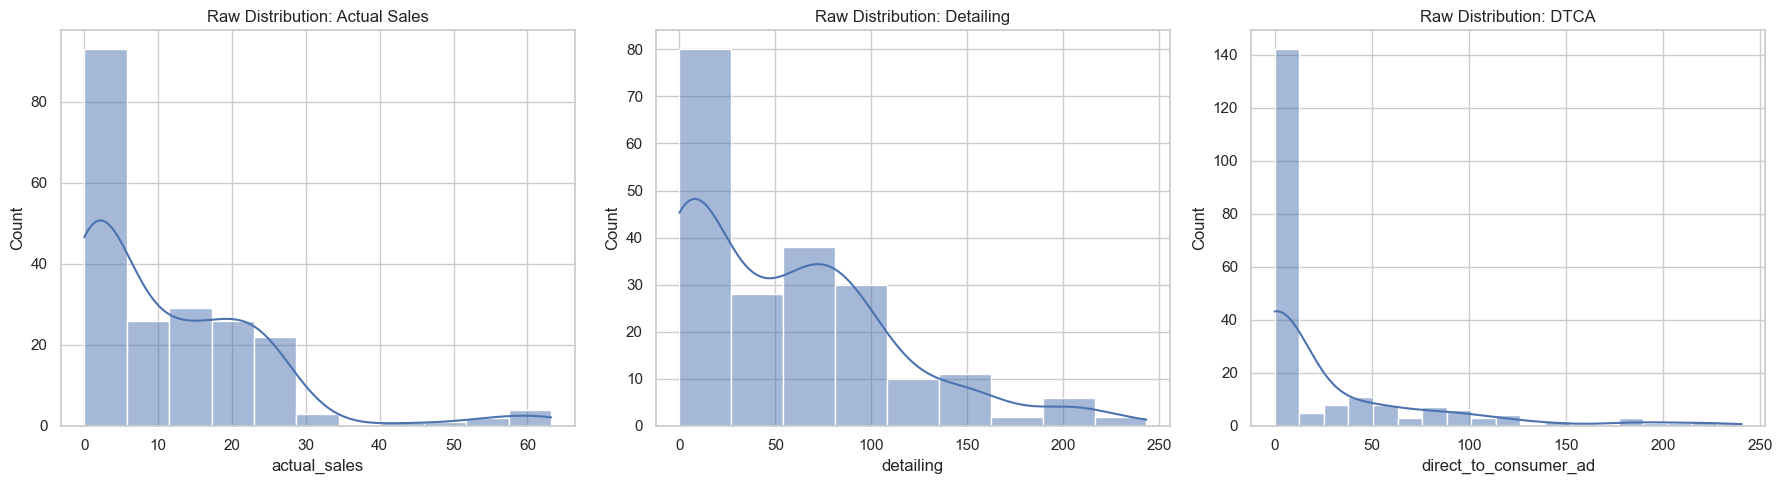

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["actual_sales"], kde=True, ax=axes[0])
axes[0].set_title("Raw Distribution: Actual Sales")

sns.histplot(df["detailing"], kde=True, ax=axes[1])
axes[1].set_title("Raw Distribution: Detailing")

sns.histplot(df["direct_to_consumer_ad"], kde=True, ax=axes[2])
axes[2].set_title("Raw Distribution: DTCA")

plt.tight_layout()
plt.show()

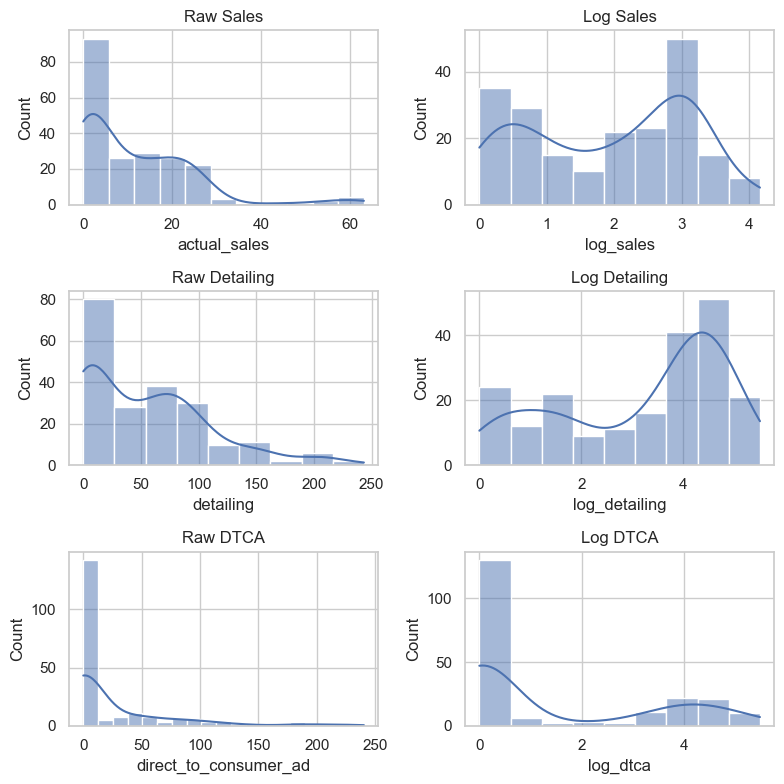

In [57]:
fig, axes = plt.subplots(3, 2, figsize=(8, 8))

sns.histplot(df["actual_sales"], kde=True, ax=axes[0,0])
axes[0,0].set_title("Raw Sales")

sns.histplot(df["log_sales"], kde=True, ax=axes[0,1])
axes[0,1].set_title("Log Sales")

sns.histplot(df["detailing"], kde=True, ax=axes[1,0])
axes[1,0].set_title("Raw Detailing")

sns.histplot(df["log_detailing"], kde=True, ax=axes[1,1])
axes[1,1].set_title("Log Detailing")

sns.histplot(df["direct_to_consumer_ad"], kde=True, ax=axes[2,0])
axes[2,0].set_title("Raw DTCA")

sns.histplot(df["log_dtca"], kde=True, ax=axes[2,1])
axes[2,1].set_title("Log DTCA")

plt.tight_layout()
plt.show()

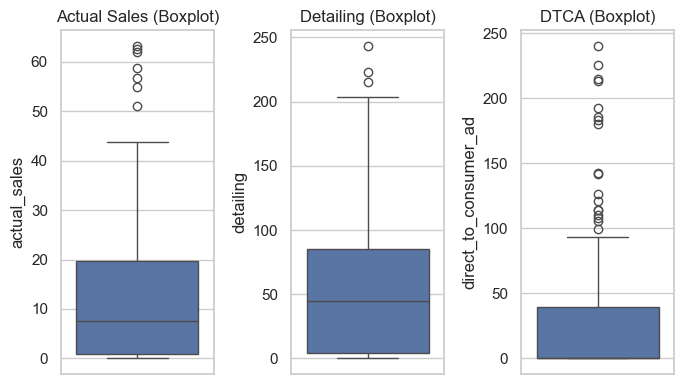

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(7, 4))

sns.boxplot(y=df["actual_sales"], ax=axes[0])
axes[0].set_title("Actual Sales (Boxplot)")

sns.boxplot(y=df["detailing"], ax=axes[1])
axes[1].set_title("Detailing (Boxplot)")

sns.boxplot(y=df["direct_to_consumer_ad"], ax=axes[2])
axes[2].set_title("DTCA (Boxplot)")

plt.tight_layout()
plt.show()


Comparing raw vs log-transformed distributions (boxplots)...


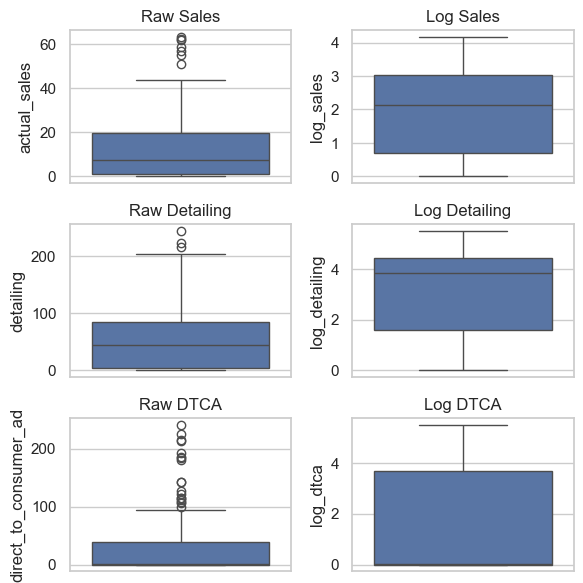


Observation: Log transformation compresses extreme values and reduces skewness.


In [54]:
print("\nComparing raw vs log-transformed distributions (boxplots)...")

fig, axes = plt.subplots(3, 2, figsize=(6, 6))

sns.boxplot(y=df["actual_sales"], ax=axes[0,0])
axes[0,0].set_title("Raw Sales")

sns.boxplot(y=df["log_sales"], ax=axes[0,1])
axes[0,1].set_title("Log Sales")

sns.boxplot(y=df["detailing"], ax=axes[1,0])
axes[1,0].set_title("Raw Detailing")

sns.boxplot(y=df["log_detailing"], ax=axes[1,1])
axes[1,1].set_title("Log Detailing")

sns.boxplot(y=df["direct_to_consumer_ad"], ax=axes[2,0])
axes[2,0].set_title("Raw DTCA")

sns.boxplot(y=df["log_dtca"], ax=axes[2,1])
axes[2,1].set_title("Log DTCA")

plt.tight_layout()
plt.show()

print("\nObservation: Log transformation compresses extreme values and reduces skewness.")

In [47]:
print("\nCalculating skewness for raw variables...")

skew_before = df[["actual_sales", "detailing", "direct_to_consumer_ad"]].skew()

display(skew_before.to_frame("skewness"))

print("\n[EDA] Observation: Positive skew indicates long right tails in distributions.")


Calculating skewness for raw variables...


,skewness
actual_sales,1.7127
detailing,1.0358
direct_to_consumer_ad,2.2988



[EDA] Observation: Positive skew indicates long right tails in distributions.


### Interpretation of Raw Distributions

- All three variables (actual_sales, detailing, and DTCA) exhibit strong right-skewness, as confirmed by both visual inspection and skewness statistics.
- DTCA shows the highest skewness (~2.30), driven by a large number of zero or near-zero observations and a few very large values.
- This indicates that most drugs receive low or no consumer advertising, while a few receive very high investment.
- Similarly, sales and detailing show long right tails, suggesting that a small number of drugs dominate in terms of marketing intensity and sales.

These distributional characteristics violate the assumptions of linear regression, particularly:
- normality of residuals
- constant variance (homoscedasticity)

Therefore, a transformation is required before modeling.

## 2. Feature engineering for EDA

We create log-transformed variables for later visual inspection.
`log1p(x)` is used so zero values can be handled safely.

In [48]:
print("\n[EDA] Applying log(1+x) transformation to stabilize variance...")

df["log_sales"] = np.log1p(df["actual_sales"])
df["log_detailing"] = np.log1p(df["detailing"])
df["log_dtca"] = np.log1p(df["direct_to_consumer_ad"])

print("[EDA] Log transformation completed.")

df["dtca_zero"] = (df["direct_to_consumer_ad"] == 0).astype(int)

df["detailing_intensity"] = df["detailing"] / df["actual_sales"]
df["dtca_intensity"] = df["direct_to_consumer_ad"] / df["actual_sales"]

df.head()


[EDA] Applying log(1+x) transformation to stabilize variance...
[EDA] Log transformation completed.


,class,agent,year,detailing,direct_to_consumer_ad,actual_sales,log_sales,log_detailing,log_dtca,dtca_zero,detailing_intensity,dtca_intensity
0,PPI,Prevacid,2013,43.8805,0.0000,2.9083,1.3631,3.8040,0.0000,1,15.0881,0.0000
1,PPI,Prilosec,2013,41.6480,0.0000,14.7235,2.7552,3.7530,0.0000,1,2.8287,0.0000
2,SSRI,Luvox,2013,22.3667,0.0000,0.9120,0.6482,3.1513,0.0000,1,24.5244,0.0000
3,SSRI,Paxil,2013,57.4608,0.0000,11.2677,2.5070,4.0684,0.0000,1,5.0996,0.0000
4,SSRI,Prozac,2013,84.5333,0.0000,20.2600,3.0568,4.4489,0.0000,1,4.1724,0.0000


In [49]:
print("\nRecomputing skewness after log transformation...")
skew_before = df[["actual_sales", "detailing", "direct_to_consumer_ad"]].skew()
skew_after = df[["log_sales", "log_detailing", "log_dtca"]].skew()

skew_compare = pd.DataFrame({
    "Before": skew_before,
    "After": skew_after
})

display(skew_compare)

print("\nObservation: Skewness is reduced, indicating more symmetric distributions.")


Recomputing skewness after log transformation...


,Before,After
actual_sales,1.7127,NaN
detailing,1.0358,NaN
direct_to_consumer_ad,2.2988,NaN
log_detailing,NaN,-0.6077
log_dtca,NaN,0.8257
log_sales,NaN,-0.1557



Observation: Skewness is reduced, indicating more symmetric distributions.


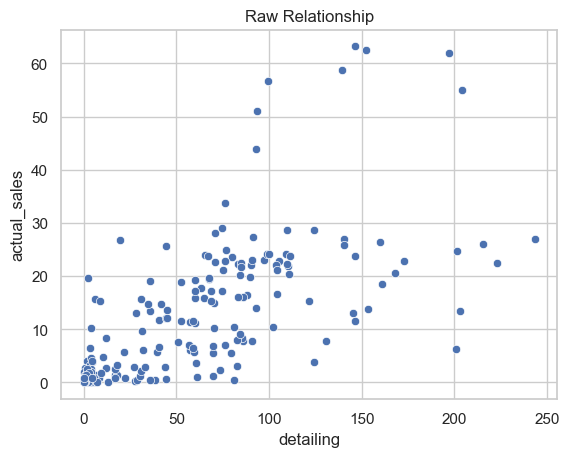

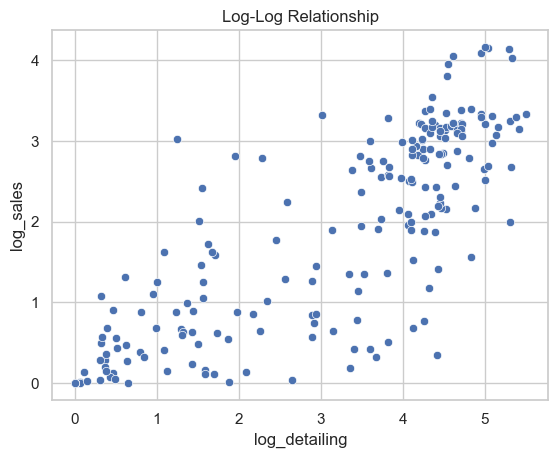

In [38]:
sns.scatterplot(x=df["detailing"], y=df["actual_sales"])
plt.title("Raw Relationship")
plt.show()

sns.scatterplot(x=df["log_detailing"], y=df["log_sales"])
plt.title("Log-Log Relationship")
plt.show()

## 3. Summary statistics

Use this section to understand central tendency, spread, and overall scale.

In [6]:
display(df[[
    "actual_sales", "detailing", "direct_to_consumer_ad",
    "log_sales", "log_detailing", "log_dtca"
]].describe())

,actual_sales,detailing,direct_to_consumer_ad,log_sales,log_detailing,log_dtca
count,207.0000,207.0000,207.0000,207.0000,207.0000,207.0000
mean,11.6705,56.0344,26.3205,1.9291,3.1922,1.4412
std,12.9729,54.9174,49.2997,1.2110,1.6343,1.9617
min,0.0002,0.0000,0.0000,0.0002,0.0000,0.0000
25%,0.9862,3.8650,0.0000,0.6862,1.5821,0.0000
50%,7.5298,44.9693,0.0025,2.1436,3.8280,0.0025
75%,19.6150,85.1234,39.3559,3.0260,4.4558,3.6971
max,63.2186,243.3303,240.3550,4.1623,5.4985,5.4863


### Interpretation

The raw distributions of sales, detailing, and DTCA are highly right-skewed, with several extreme values.

After applying log transformations:
- The distributions become more balanced, with reduced skewness.
- Extreme values are compressed, reducing their influence.
- The boxplots show a more symmetric spread around the median.

The log-log scatterplot between detailing and sales reveals a clear positive and approximately linear relationship, which was not evident in the raw scale.

This indicates that:
- the relationship between marketing effort and sales is multiplicative rather than additive
- log-log models are appropriate for capturing this relationship
- coefficients can be interpreted as elasticities

Overall, the transformation improves both distributional properties and the interpretability of relationships.

In [7]:
class_summary = (
    df.groupby("class")[["actual_sales", "detailing", "direct_to_consumer_ad"]]
      .agg(["mean", "std", "min", "max"])
      .sort_values(("actual_sales", "mean"), ascending=False)
)

class_summary

actual_sales                        detailing                          \
               mean     std    min     max      mean     std    min      max   
class                                                                          
PPI         13.8355  8.9010 0.2054 28.9983   78.5221 45.7602 2.4873 172.8186   
Statin      12.4964 16.8686 0.0008 63.2186   48.5592 53.6895 0.1510 203.9765   
SSRI         9.5923 10.2513 0.0002 28.7552   49.9067 58.0119 0.0000 243.3303   

       direct_to_consumer_ad                          
                        mean     std    min      max  
class                                                 
PPI                  42.9419 69.4016 0.0000 240.3550  
Statin               31.7618 49.7525 0.0000 213.3158  
SSRI                 11.2310 24.9208 0.0000 114.1849

In [8]:
agent_summary = (
    df.groupby("agent")[["actual_sales", "detailing", "direct_to_consumer_ad"]]
      .agg(["mean", "std"])
      .sort_values(("actual_sales", "mean"), ascending=False)
)

agent_summary.head(10)

actual_sales         detailing         direct_to_consumer_ad        
                 mean     std      mean     std                  mean     std
agent                                                                        
Lipitor       47.0275 18.3517  124.0093 46.9129               80.7884 54.8270
Zoloft        21.1441  7.5867   80.4162 35.6358               30.3664 39.4560
Lexapro       19.1402 10.0567  192.7008 62.1090                0.7499  0.9507
Nexium        18.7587  8.0302  153.0828 17.1630              182.8566 52.3960
Prevacid      17.8747  7.1570   92.0651 28.5974               38.7137 46.8363
Zocor         17.6050  6.7210   70.3491 33.8493               54.1879 33.5656
Prilosec      14.1557 11.6924   27.1468 29.3306               23.3186 37.2672
Paxil         12.8184  9.7939   43.0369 35.4293               22.7528 36.1984
Protonix      12.0249  5.9005   83.2735 13.3897                3.3244  6.2799
Prozac        11.2791 10.8142   36.9844 37.5657                7.0337 13.0253

## 4. Distribution checks

These plots address:
- distribution of sales
- distribution of detailing
- distribution of DTCA

Use these visuals to assess skewness, outliers, and whether log transformations are justified.

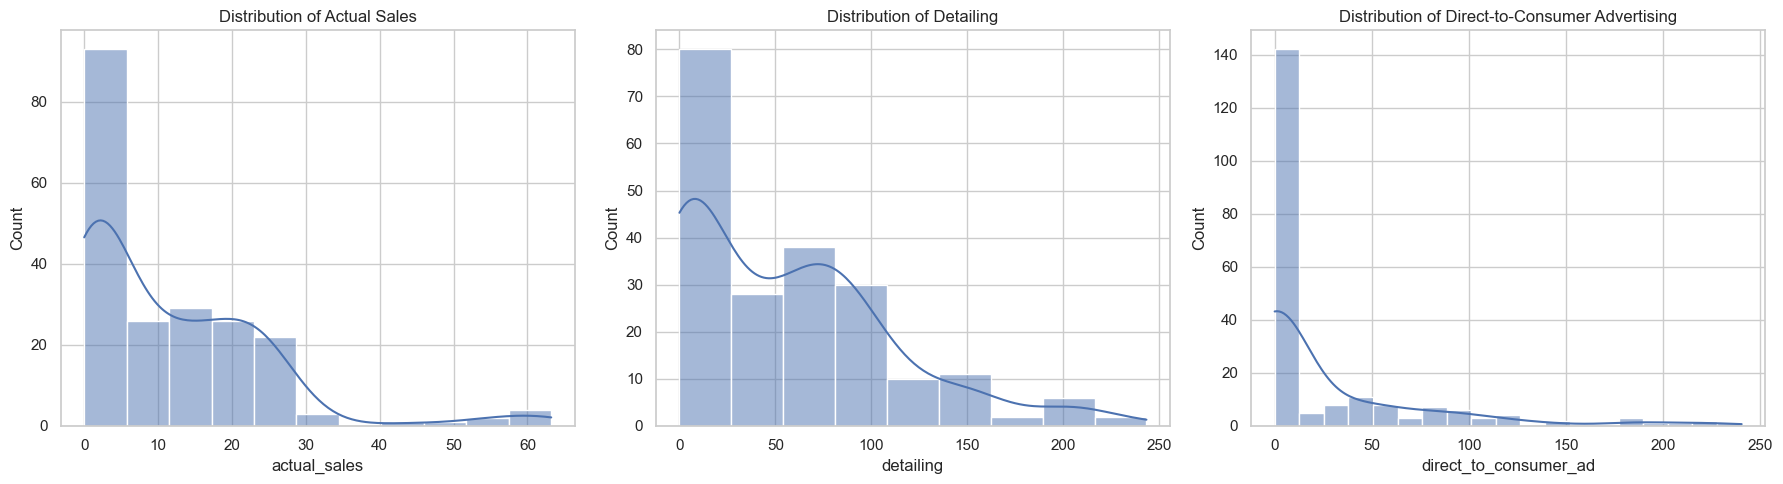

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["actual_sales"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Actual Sales")

sns.histplot(df["detailing"], kde=True, ax=axes[1])
axes[1].set_title("Distribution of Detailing")

sns.histplot(df["direct_to_consumer_ad"], kde=True, ax=axes[2])
axes[2].set_title("Distribution of Direct-to-Consumer Advertising")

plt.tight_layout()
plt.show()

## 5. Zero values in direct-to-consumer advertising

This is important because zero DTCA is not just “small DTCA”; it may represent a different marketing regime.

In [10]:
print("Overall zero-DTCA count:")
display(df["dtca_zero"].value_counts().rename(index={0: "non_zero", 1: "zero"}).to_frame("count"))

print("\nZero-DTCA by class:")
display(pd.crosstab(df["class"], df["dtca_zero"]))

print("\nZero-DTCA by year:")
display(pd.crosstab(df["year"], df["dtca_zero"]))

Overall zero-DTCA count:


,count
dtca_zero,
non_zero,109
zero,98



Zero-DTCA by class:


dtca_zero,0,1
class,,
PPI,32,16
SSRI,34,47
Statin,43,35



Zero-DTCA by year:


dtca_zero,0,1
year,,
2013,3,7
2014,5,6
2015,6,6
2016,6,7
2017,7,8
2018,12,5
2019,12,8
2020,10,11
2021,13,9


## 6. Trends over year

These plots show how average sales, detailing, and DTCA evolve over time.

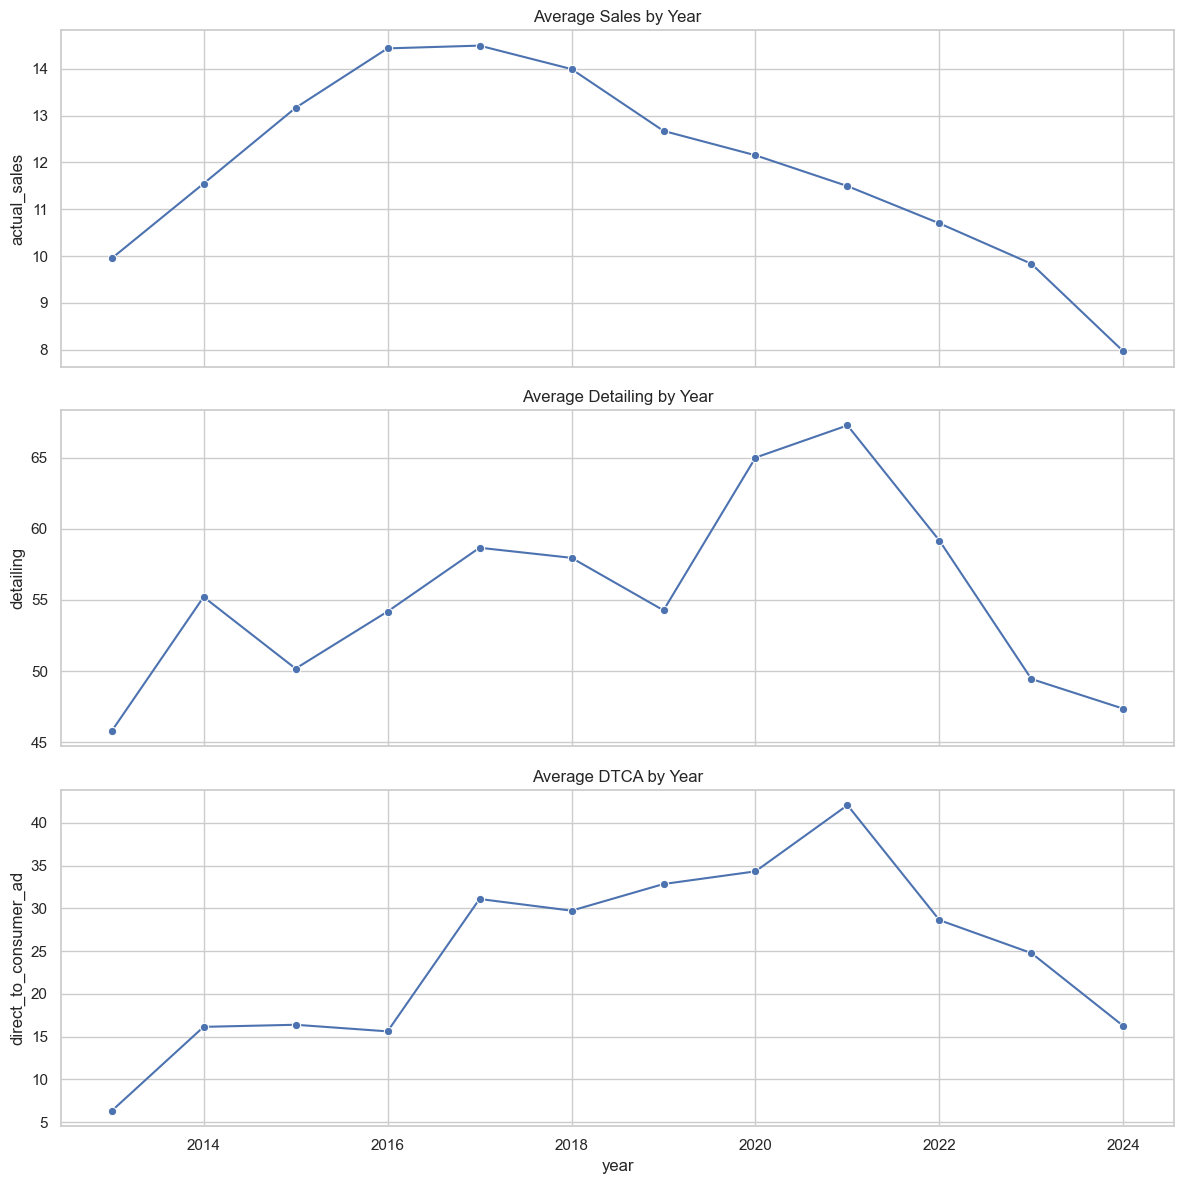

In [11]:
yearly = (
    df.groupby("year")[["actual_sales", "detailing", "direct_to_consumer_ad"]]
      .mean()
      .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

sns.lineplot(data=yearly, x="year", y="actual_sales", marker="o", ax=axes[0])
axes[0].set_title("Average Sales by Year")

sns.lineplot(data=yearly, x="year", y="detailing", marker="o", ax=axes[1])
axes[1].set_title("Average Detailing by Year")

sns.lineplot(data=yearly, x="year", y="direct_to_consumer_ad", marker="o", ax=axes[2])
axes[2].set_title("Average DTCA by Year")

plt.tight_layout()
plt.show()

### Trends by class

The aggregate trend can hide class-level differences. This plot helps assess whether year effects look common or class-specific.

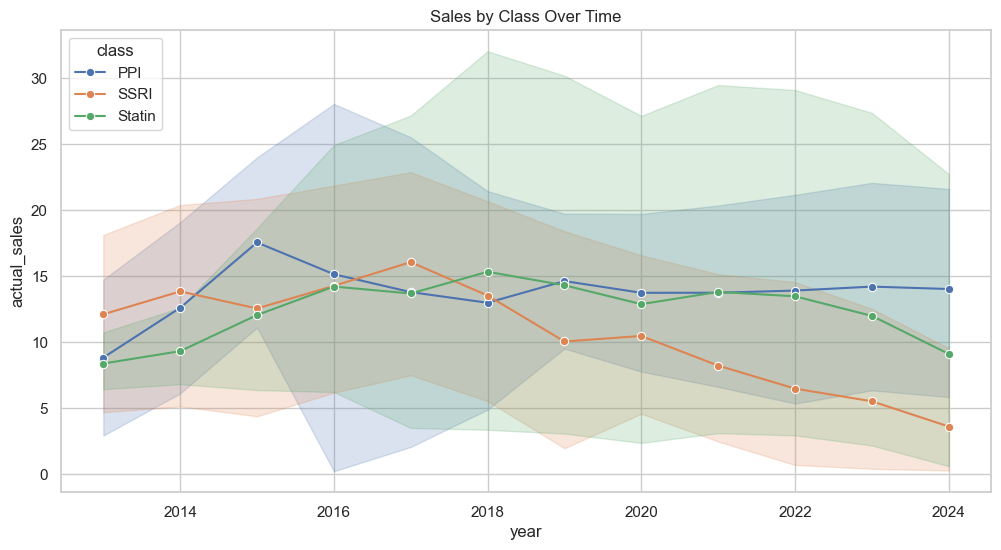

In [12]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="year", y="actual_sales", hue="class", marker="o")
plt.title("Sales by Class Over Time")
plt.show()

## 7. Average sales by class and agent

These tables help check whether some classes or agents appear to have systematically different baselines.

In [13]:
avg_sales_by_class = (
    df.groupby("class")["actual_sales"]
      .mean()
      .sort_values(ascending=False)
      .to_frame("avg_actual_sales")
)

avg_sales_by_class

,avg_actual_sales
class,
PPI,13.8355
Statin,12.4964
SSRI,9.5923


In [14]:
avg_sales_by_agent = (
    df.groupby("agent")["actual_sales"]
      .mean()
      .sort_values(ascending=False)
      .to_frame("avg_actual_sales")
)

avg_sales_by_agent.head(15)

,avg_actual_sales
agent,
Lipitor,47.0275
Zoloft,21.1441
Lexapro,19.1402
Nexium,18.7587
Prevacid,17.8747
Zocor,17.6050
Prilosec,14.1557
Paxil,12.8184
Protonix,12.0249


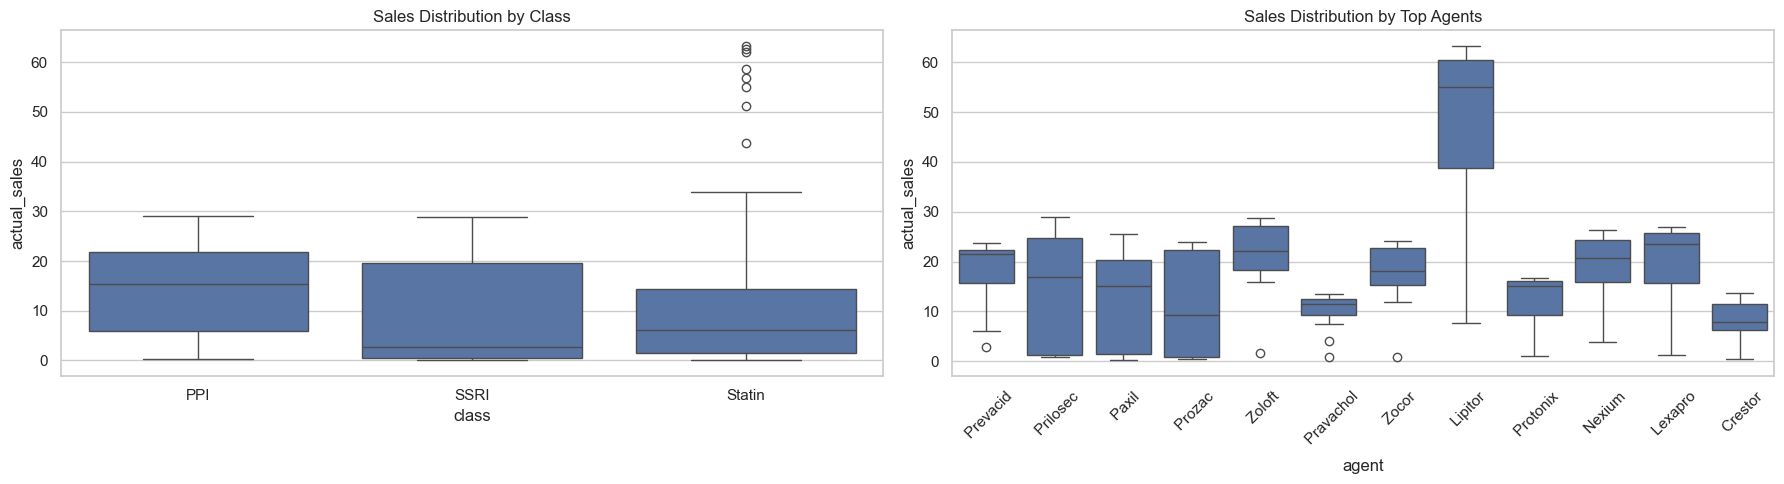

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.boxplot(data=df, x="class", y="actual_sales", ax=axes[0])
axes[0].set_title("Sales Distribution by Class")

top_agents = avg_sales_by_agent.head(12).index
sns.boxplot(data=df[df["agent"].isin(top_agents)], x="agent", y="actual_sales", ax=axes[1])
axes[1].set_title("Sales Distribution by Top Agents")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 8. Scatterplots on the raw scale

These directly address:
- sales vs detailing
- sales vs DTCA

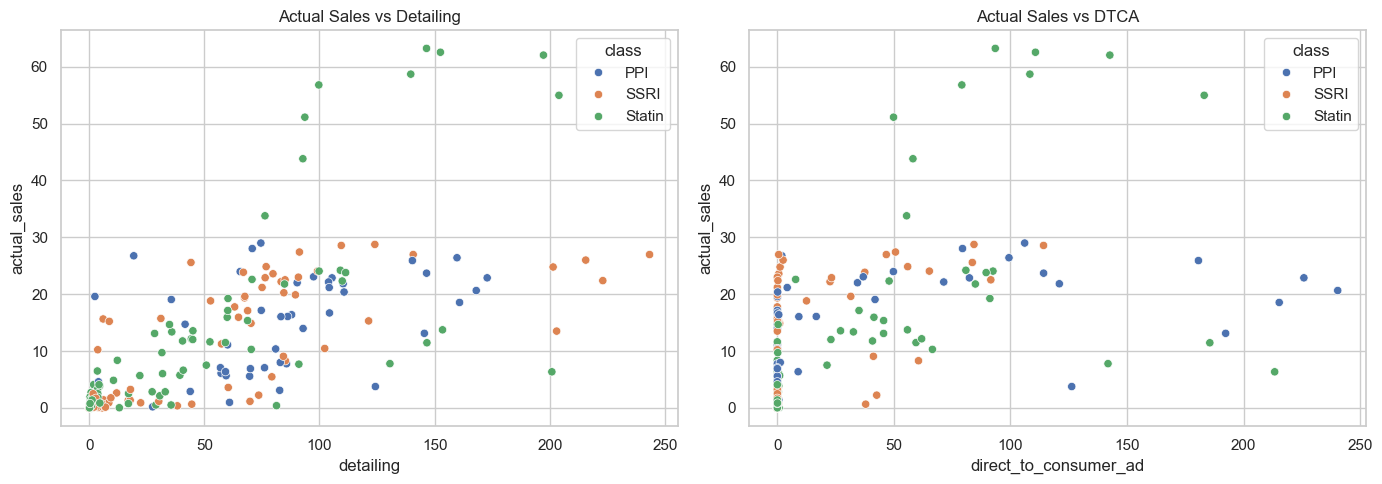

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="detailing", y="actual_sales", hue="class", ax=axes[0])
axes[0].set_title("Actual Sales vs Detailing")

sns.scatterplot(data=df, x="direct_to_consumer_ad", y="actual_sales", hue="class", ax=axes[1])
axes[1].set_title("Actual Sales vs DTCA")

plt.tight_layout()
plt.show()

## 9. Log-transformed relationships

These plots help assess whether a log-log specification produces a cleaner relationship than the raw scale.

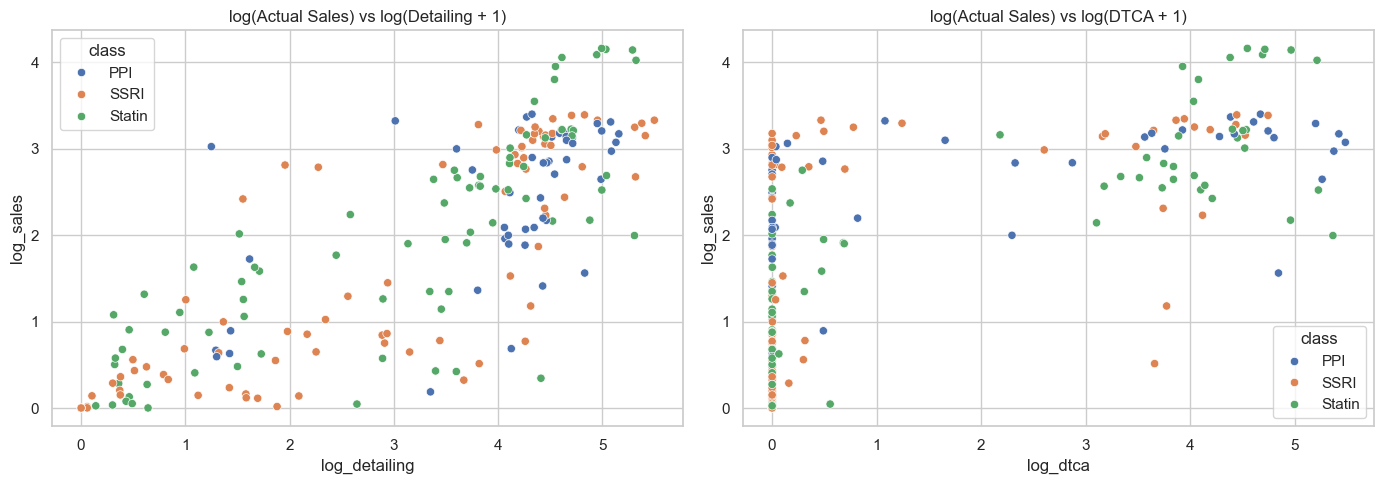

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="log_detailing", y="log_sales", hue="class", ax=axes[0])
axes[0].set_title("log(Actual Sales) vs log(Detailing + 1)")

sns.scatterplot(data=df, x="log_dtca", y="log_sales", hue="class", ax=axes[1])
axes[1].set_title("log(Actual Sales) vs log(DTCA + 1)")

plt.tight_layout()
plt.show()

### Faceted class-level response plots

Coloring by class is helpful, but faceting makes slope differences easier to inspect visually.

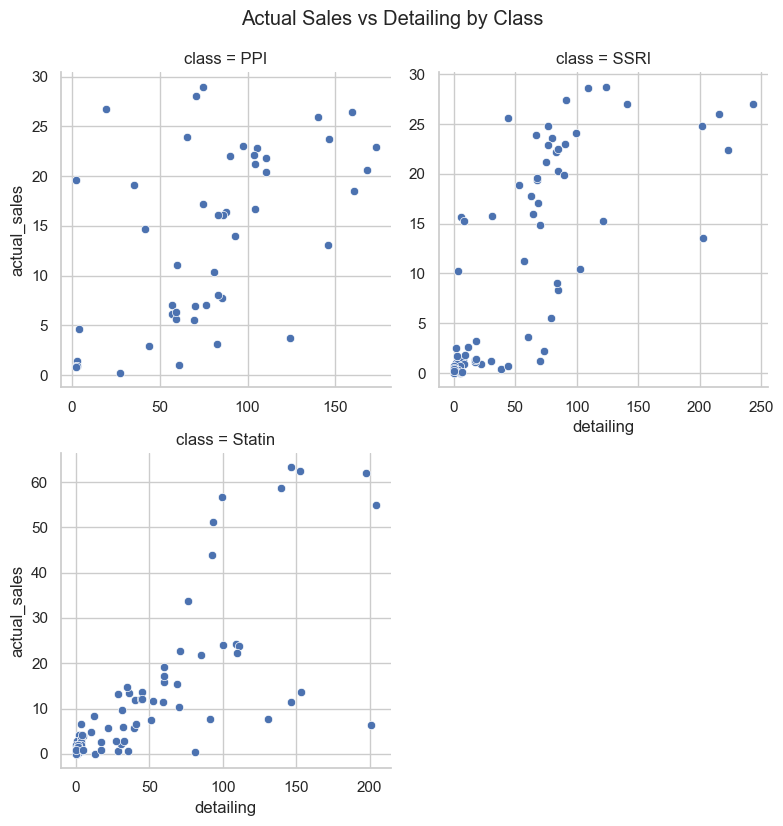

In [18]:
g = sns.FacetGrid(df, col="class", col_wrap=2, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.scatterplot, x="detailing", y="actual_sales")
g.fig.suptitle("Actual Sales vs Detailing by Class", y=1.03)
plt.show()

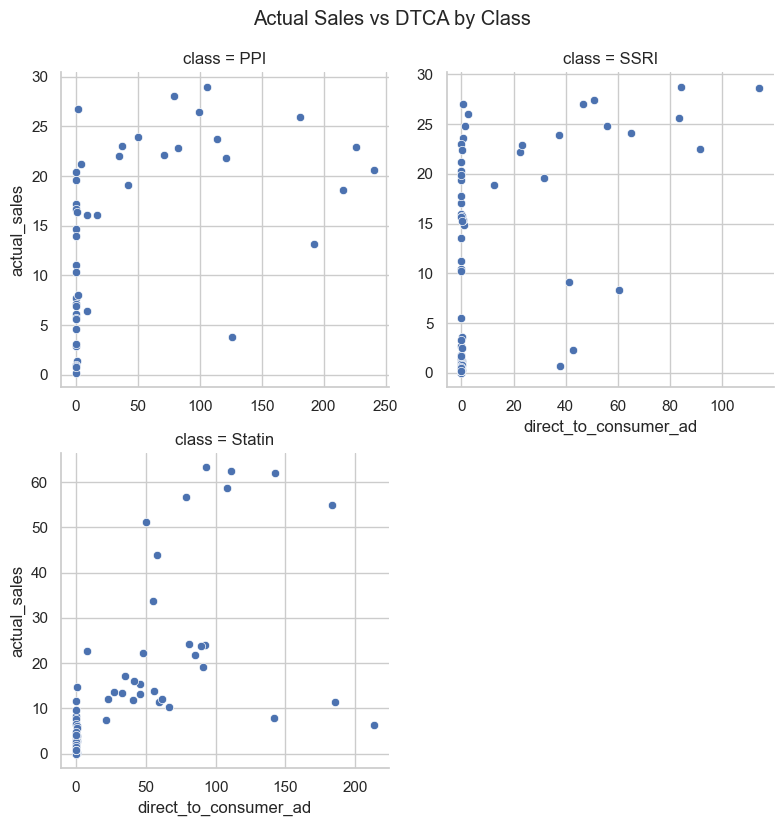

In [19]:
g = sns.FacetGrid(df, col="class", col_wrap=2, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.scatterplot, x="direct_to_consumer_ad", y="actual_sales")
g.fig.suptitle("Actual Sales vs DTCA by Class", y=1.03)
plt.show()

## 10. Correlation matrix

Use one clean matrix rather than mixing raw and transformed versions of the same variables.

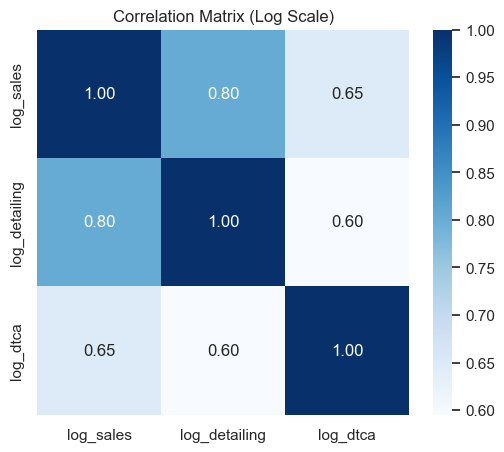

In [20]:
corr = df[["log_sales", "log_detailing", "log_dtca"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix (Log Scale)")
plt.show()

## 11. Relationship between detailing and DTCA

This helps identify whether the two marketing inputs tend to move together, which matters for coefficient separation later.

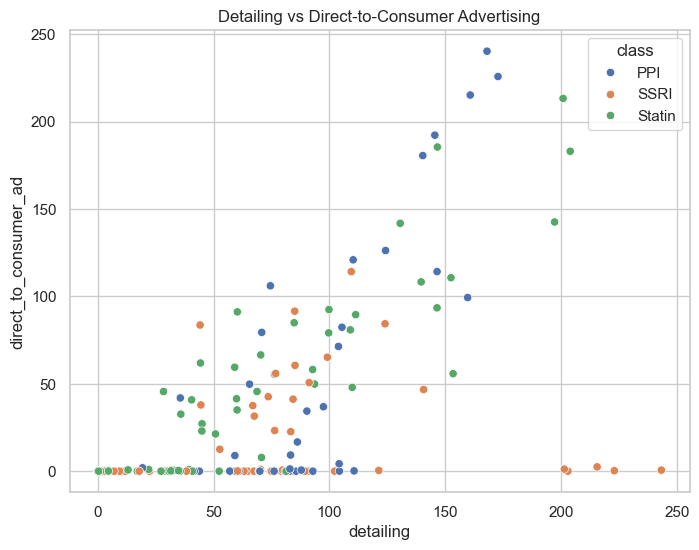

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="detailing",
    y="direct_to_consumer_ad",
    hue="class"
)
plt.title("Detailing vs Direct-to-Consumer Advertising")
plt.show()

## 12. Within-agent variation

Because this is panel-style data, it is not enough to know whether bigger brands spend more and sell more.  
We also want to see whether sales and marketing move together within the same agent over time.

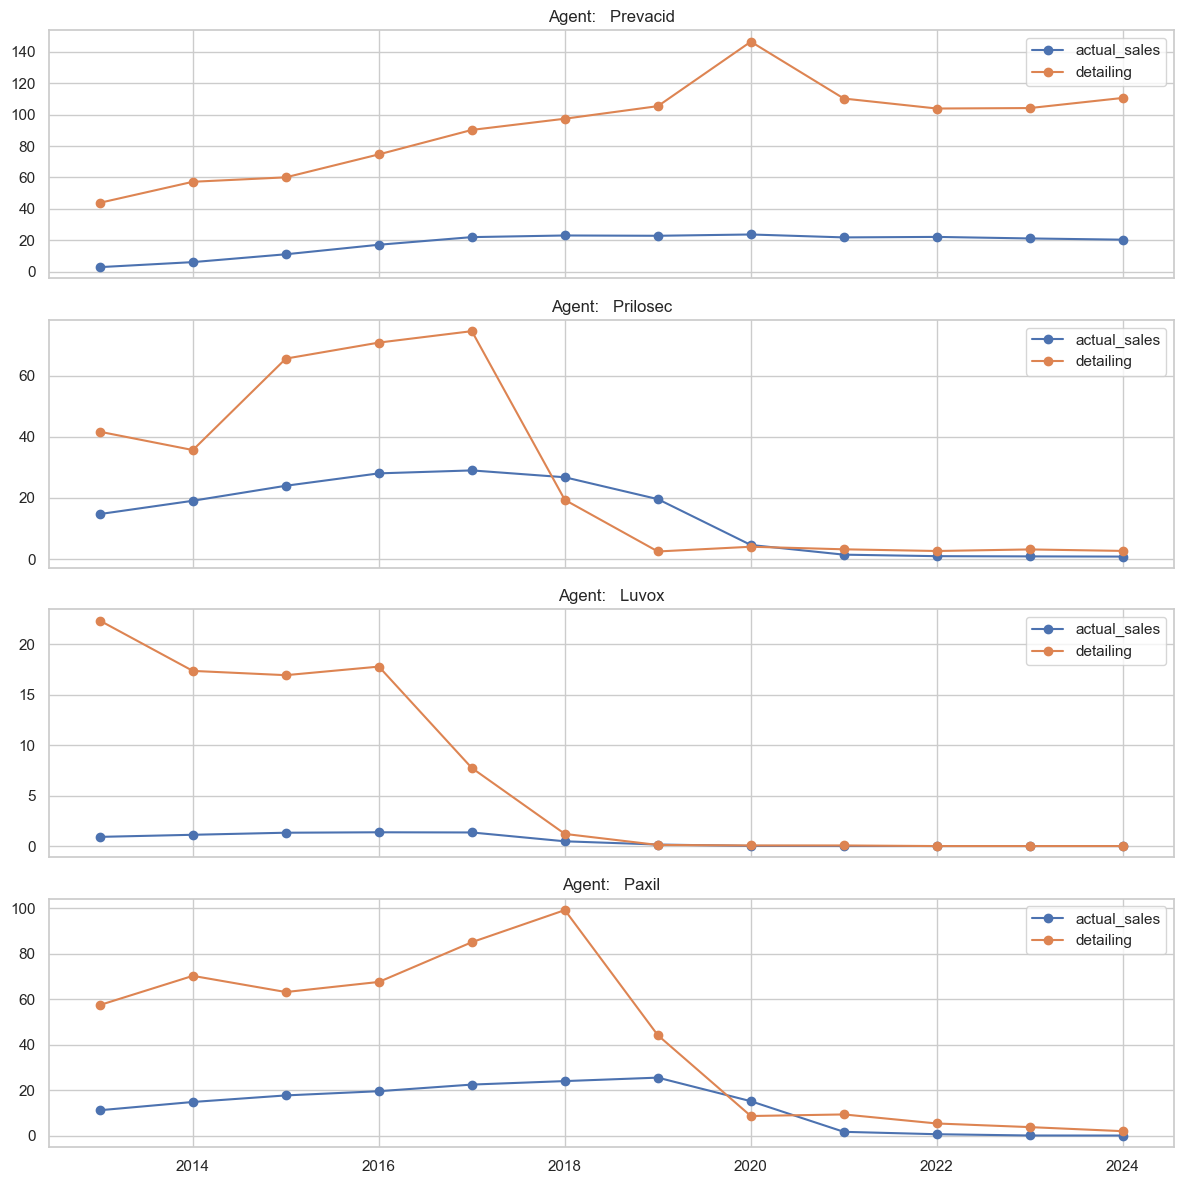

In [22]:
sample_agents = df["agent"].drop_duplicates().head(4).tolist()

fig, axes = plt.subplots(len(sample_agents), 1, figsize=(12, 12), sharex=True)

for i, a in enumerate(sample_agents):
    temp = df[df["agent"] == a].sort_values("year")

    axes[i].plot(temp["year"], temp["actual_sales"], marker="o", label="actual_sales")
    axes[i].plot(temp["year"], temp["detailing"], marker="o", label="detailing")
    axes[i].set_title(f"Agent: {a}")
    axes[i].legend()

plt.tight_layout()
plt.show()

## 13. Marketing intensity

These ratios are descriptive only, but they can reveal whether some classes are more marketing-intensive relative to sales.

In [23]:
intensity_summary = (
    df.groupby("class")[["detailing_intensity", "dtca_intensity"]]
      .mean()
      .sort_values("detailing_intensity", ascending=False)
)

intensity_summary

,detailing_intensity,dtca_intensity
class,,
Statin,26.1372,2.1452
SSRI,14.2837,1.4505
PPI,10.8533,2.6465


## 14. Outlier check

This section surfaces the largest observations in the main business variables.

In [24]:
print("Top 5 by actual sales")
display(df.nlargest(5, "actual_sales")[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]])

print("Top 5 by detailing")
display(df.nlargest(5, "detailing")[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]])

print("Top 5 by DTCA")
display(df.nlargest(5, "direct_to_consumer_ad")[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]])

Top 5 by actual sales


,class,agent,year,actual_sales,detailing,direct_to_consumer_ad
159,Statin,Lipitor,2022,63.2186,146.4874,93.4800
137,Statin,Lipitor,2021,62.5406,152.5107,110.7082
181,Statin,Lipitor,2023,62.0389,197.2503,142.6181
115,Statin,Lipitor,2020,58.6918,139.6403,108.3209
94,Statin,Lipitor,2019,56.7952,99.7099,79.1343


Top 5 by detailing


,class,agent,year,actual_sales,detailing,direct_to_consumer_ad
191,SSRI,Lexapro,2024,26.9766,243.3303,0.5963
125,SSRI,Lexapro,2021,22.3924,223.0231,0.2595
169,SSRI,Lexapro,2023,26.0019,215.6069,2.4667
203,Statin,Lipitor,2024,54.9727,203.9765,183.0804
104,SSRI,Lexapro,2020,13.5176,202.9746,0.0000


Top 5 by DTCA


,class,agent,year,actual_sales,detailing,direct_to_consumer_ad
120,PPI,Nexium,2021,20.6499,168.0683,240.3550
142,PPI,Nexium,2022,22.8833,172.8186,225.8439
99,PPI,Nexium,2020,18.5523,160.8279,215.2616
134,Statin,Crestor,2021,6.3594,200.9031,213.3158
79,PPI,Nexium,2019,13.1240,145.5416,192.2922


## 15. EDA takeaways

Use this section to write short, evidence-based takeaways after running the notebook.

### Suggested prompts
- Are the variables right-skewed?
- Do the log-transformed plots look more linear?
- Are zero-DTCA observations common or concentrated in certain classes/years?
- Do class baselines look different enough to justify fixed effects?
- Do class-level response plots suggest interaction terms?
- Do sales and detailing move together within some agents over time?
- Is there any obvious collinearity concern between detailing and DTCA?

In [ ]:
# Optional: save a processed EDA dataset for the next notebooks
df.to_csv("../data/processed_data.csv", index=False)
print("Saved: ../data/processed_data.csv")